# Cognifyz Data Science Internship
# Name: RAGHUL K
## Email ID: raghul1826@gmail.com
## Level 2 — Tasks 1, 2 & 3
**Dataset:** Zomato Restaurant Dataset  
**Level 2 covers:** Table Booking & Online Delivery | Price Range Analysis | Feature Engineering

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load & Preprocess (mirror Level 1 cleaning) ───────────────────────────────
df = pd.read_csv("C:/Users/RAGHUL K/OneDrive/Documents/Jupyter/Dataset.csv")
df['Cuisines'].fillna('Unknown', inplace=True)

binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(f'Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(2)

Dataset ready: 9551 rows × 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,0,0,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,0,0,3,4.5,Dark Green,Excellent,591


---
## Task 1 — Table Booking & Online Delivery

### 1.1 — Percentage of Restaurants Offering Each Service

Restaurants with Table Booking  : 12.12%
Restaurants with Online Delivery: 25.66%


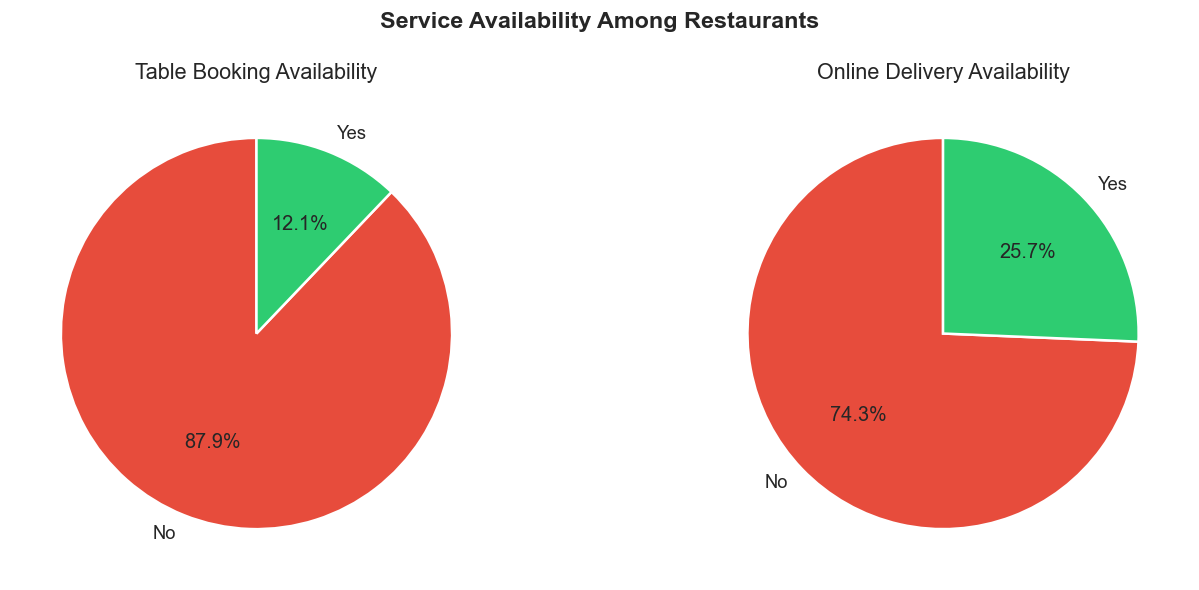

In [3]:
total = len(df)
pct_table    = df['Has Table booking'].mean() * 100
pct_delivery = df['Has Online delivery'].mean() * 100

print(f'Restaurants with Table Booking  : {pct_table:.2f}%')
print(f'Restaurants with Online Delivery: {pct_delivery:.2f}%')

# Pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ['Has Table booking', 'Has Online delivery'],
    ['Table Booking', 'Online Delivery']
):
    counts = df[col].value_counts()
    ax.pie(
        counts,
        labels=['No', 'Yes'],
        autopct='%1.1f%%',
        colors=['#e74c3c', '#2ecc71'],
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    ax.set_title(f'{title} Availability', fontsize=13)

plt.suptitle('Service Availability Among Restaurants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 — Average Ratings: Table Booking vs No Table Booking

Average Rating by Table Booking:
                    mean  median  count
No Table Booking   3.414     3.4   6292
Has Table Booking  3.588     3.6   1111


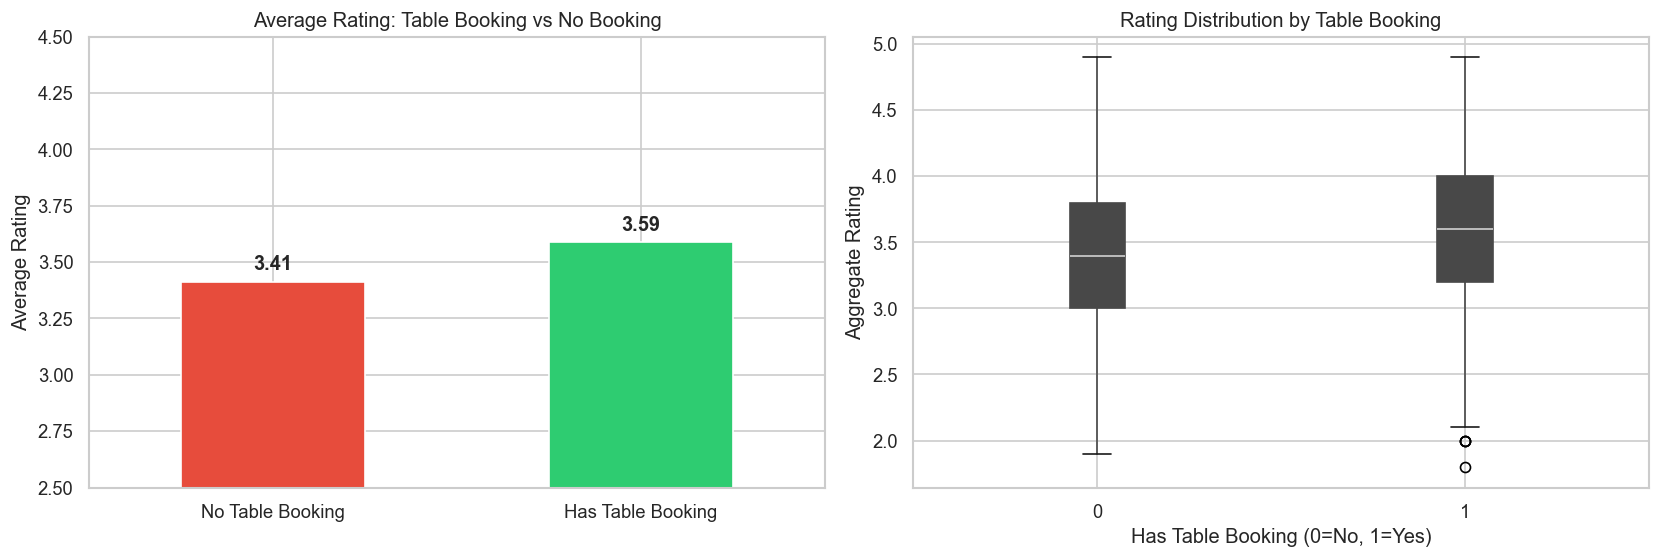

In [4]:
# Exclude unrated (0.0) from rating comparisons
rated = df[df['Aggregate rating'] > 0].copy()

avg_by_booking = rated.groupby('Has Table booking')['Aggregate rating'].agg(['mean', 'median', 'count'])
avg_by_booking.index = ['No Table Booking', 'Has Table Booking']
print('Average Rating by Table Booking:')
print(avg_by_booking.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
avg_by_booking['mean'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
                            edgecolor='white')
axes[0].set_title('Average Rating: Table Booking vs No Booking')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(2.5, 4.5)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(avg_by_booking['mean']):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Box plot
rated.boxplot(column='Aggregate rating', by='Has Table booking', ax=axes[1],
              patch_artist=True)
axes[1].set_title('Rating Distribution by Table Booking')
axes[1].set_xlabel('Has Table Booking (0=No, 1=Yes)')
axes[1].set_ylabel('Aggregate Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 1.3 — Online Delivery Availability Across Price Ranges

Online Delivery availability (%) by Price Range:
Price range
1    15.77
2    41.31
3    29.19
4     9.04
Name: Has Online delivery, dtype: float64


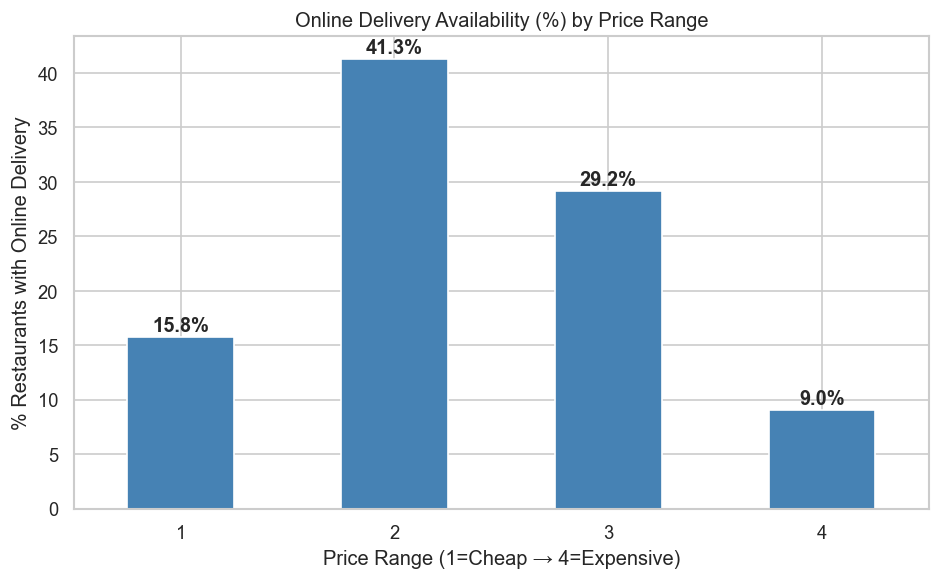

In [5]:
delivery_by_price = df.groupby('Price range')['Has Online delivery'].mean() * 100
print('Online Delivery availability (%) by Price Range:')
print(delivery_by_price.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
delivery_by_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Online Delivery Availability (%) by Price Range')
ax.set_xlabel('Price Range (1=Cheap → 4=Expensive)')
ax.set_ylabel('% Restaurants with Online Delivery')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(delivery_by_price):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Key Finding:** Restaurants with table booking have noticeably higher average ratings (~3.4 vs ~2.5). Online delivery is more common in lower-to-mid price ranges.

---
## Task 2 — Price Range Analysis

### 2.1 — Most Common Price Range

Price Range Counts:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Most Common Price Range: 1 (Count: 4444)


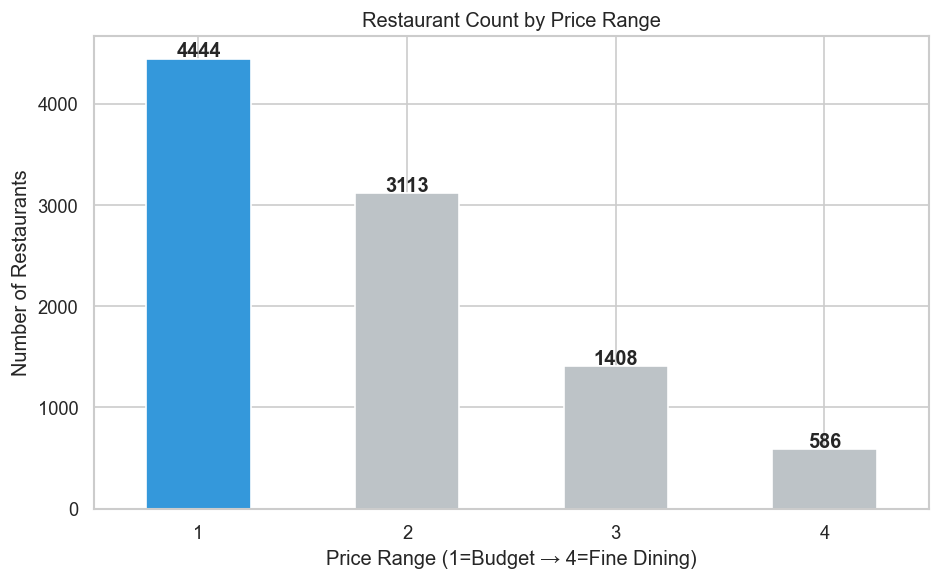

In [6]:
price_counts = df['Price range'].value_counts().sort_index()
most_common  = price_counts.idxmax()
print(f'Price Range Counts:\n{price_counts}')
print(f'\nMost Common Price Range: {most_common} (Count: {price_counts[most_common]})')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db' if i == most_common else '#bdc3c7' for i in price_counts.index]
price_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Restaurant Count by Price Range')
ax.set_xlabel('Price Range (1=Budget → 4=Fine Dining)')
ax.set_ylabel('Number of Restaurants')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(price_counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 — Average Rating per Price Range

Average Rating by Price Range:
Price range
1    3.239
2    3.377
3    3.777
4    3.891
Name: Aggregate rating, dtype: float64


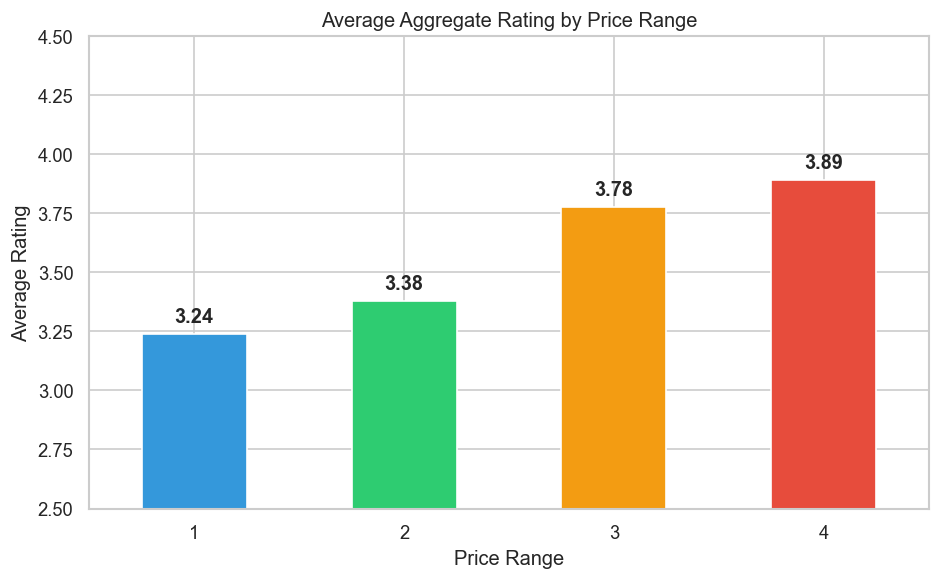

In [7]:
# Exclude unrated restaurants
rated = df[df['Aggregate rating'] > 0]

avg_rating_price = rated.groupby('Price range')['Aggregate rating'].mean().round(3)
print('Average Rating by Price Range:')
print(avg_rating_price)

fig, ax = plt.subplots(figsize=(8, 5))
bars = avg_rating_price.plot(kind='bar', ax=ax,
                              color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
                              edgecolor='white')
ax.set_title('Average Aggregate Rating by Price Range')
ax.set_xlabel('Price Range')
ax.set_ylabel('Average Rating')
ax.set_ylim(2.5, 4.5)
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(avg_rating_price):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 — Identify the Color Representing the Highest Average Rating

Average Rating by Rating Color:
               mean  count
Rating color              
Dark Green    4.660    301
Green         4.168   1079
Yellow        3.683   2100
Orange        3.052   3737
Red           2.298    186

★ Color with Highest Average Rating: "Dark Green" (4.660)


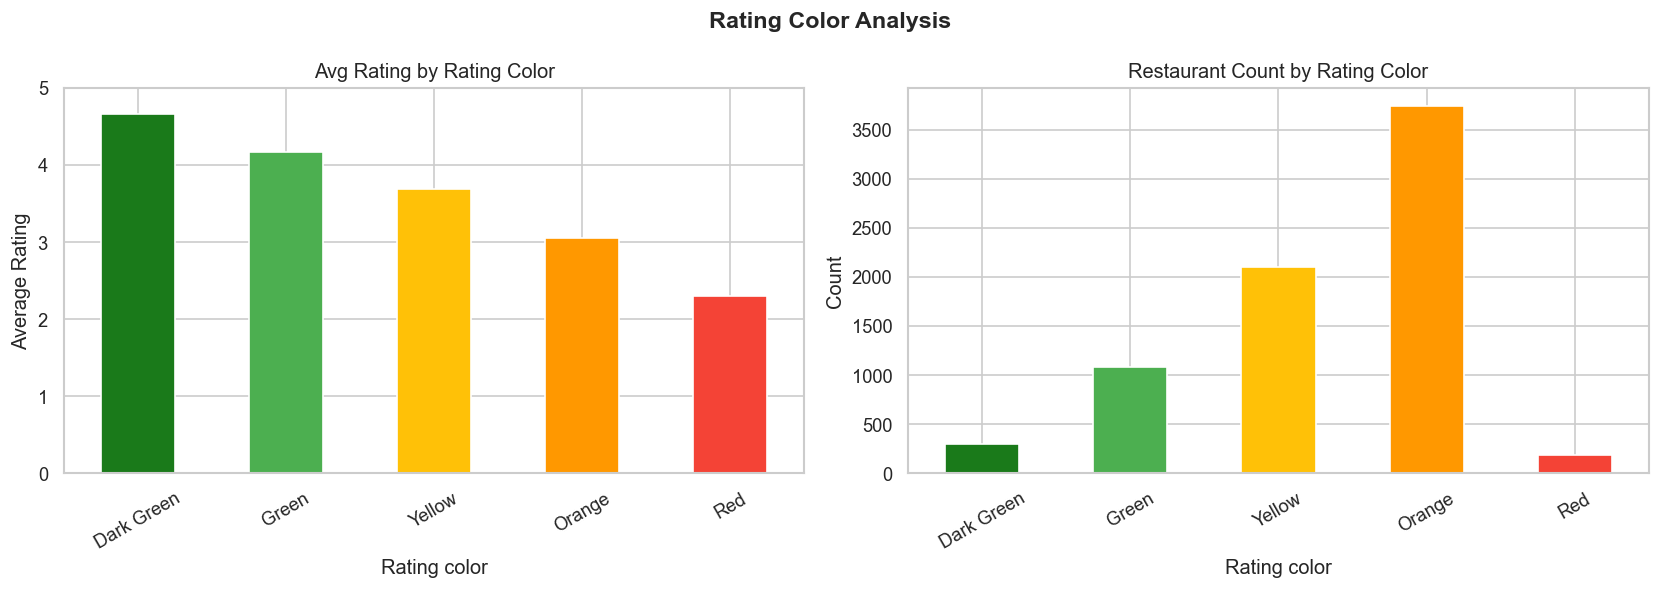

In [8]:
color_rating = (
    rated.groupby('Rating color')['Aggregate rating']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
print('Average Rating by Rating Color:')
print(color_rating.round(3))

best_color = color_rating['mean'].idxmax()
print(f'\n★ Color with Highest Average Rating: "{best_color}" ({color_rating.loc[best_color, "mean"]:.3f})')

# Map rating colors to hex approximations
color_map = {
    'Dark Green': '#1a7a1a',
    'Green'     : '#4CAF50',
    'Yellow'    : '#FFC107',
    'Orange'    : '#FF9800',
    'Red'       : '#f44336',
    'White'     : '#bdbdbd'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average rating by color
bar_colors = [color_map.get(c, 'gray') for c in color_rating.index]
color_rating['mean'].plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_title('Avg Rating by Rating Color')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=30)

# Restaurant count per color
color_rating['count'].plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('Restaurant Count by Rating Color')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Rating Color Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Finding:** Price range and rating are positively correlated — higher price range restaurants consistently receive better ratings. **Dark Green** is the color associated with the highest average rating (4.9+, "Excellent" tier).

---
## Task 3 — Feature Engineering

### 3.1 — Extract Length Features

In [9]:
# Length features from text columns
df['Name Length']         = df['Restaurant Name'].str.len()
df['Address Length']      = df['Address'].str.len()
df['Locality Length']     = df['Locality'].str.len()
df['Cuisine Count']       = df['Cuisines'].str.split(',').str.len()

print('New length-based features:')
print(df[['Restaurant Name', 'Name Length', 'Address Length', 'Cuisine Count']].head())

New length-based features:
          Restaurant Name  Name Length  Address Length  Cuisine Count
0        Le Petit Souffle           16              71            3.0
1        Izakaya Kikufuji           16              67            1.0
2  Heat - Edsa Shangri-La           22              56            4.0
3                    Ooma            4              70            2.0
4             Sambo Kojin           11              64            2.0


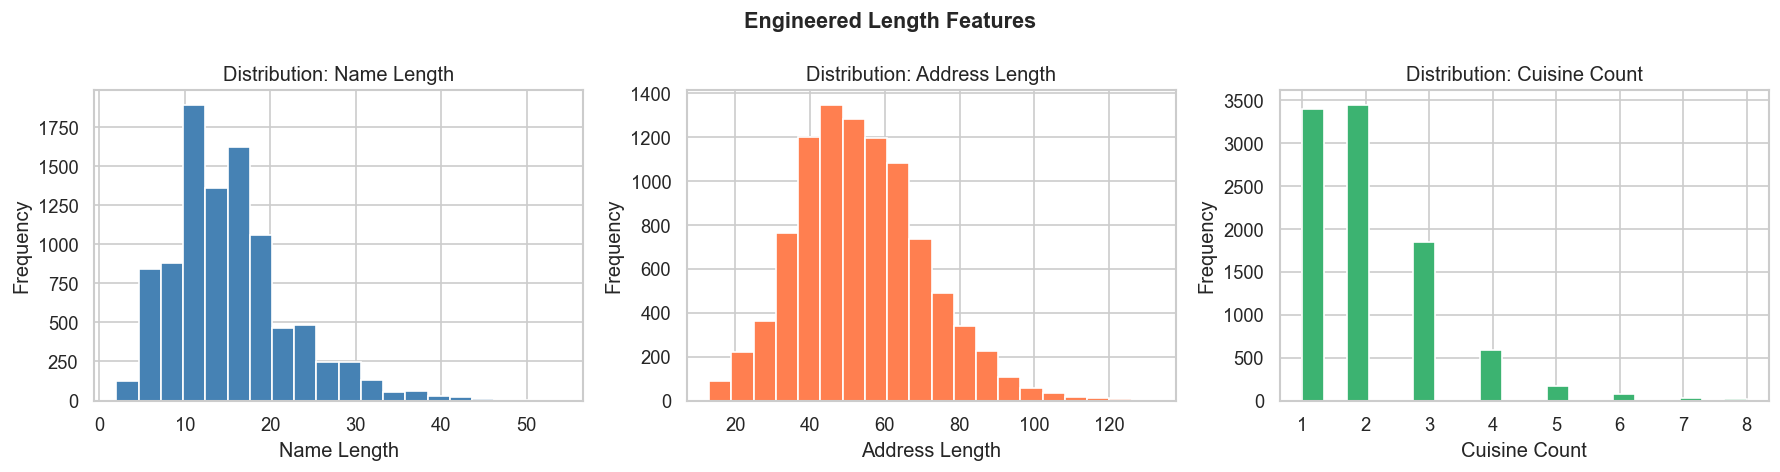

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(
    axes,
    ['Name Length', 'Address Length', 'Cuisine Count'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    ax.hist(df[col], bins=20, color=color, edgecolor='white')
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Engineered Length Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 — Binary Encoding of Categorical Service Columns

In [11]:
# Already encoded in preprocessing — confirm values
print('Binary encoded columns (sample):')
print(df[['Has Table booking', 'Has Online delivery', 'Is delivering now']].head(10))
print('\nValue counts for Has Table booking:')
print(df['Has Table booking'].value_counts())

Binary encoded columns (sample):
   Has Table booking  Has Online delivery  Is delivering now
0                  1                    0                  0
1                  1                    0                  0
2                  1                    0                  0
3                  0                    0                  0
4                  1                    0                  0
5                  0                    0                  0
6                  1                    0                  0
7                  1                    0                  0
8                  1                    0                  0
9                  1                    0                  0

Value counts for Has Table booking:
Has Table booking
0    8393
1    1158
Name: count, dtype: int64


### 3.3 — Cuisine Count vs Rating

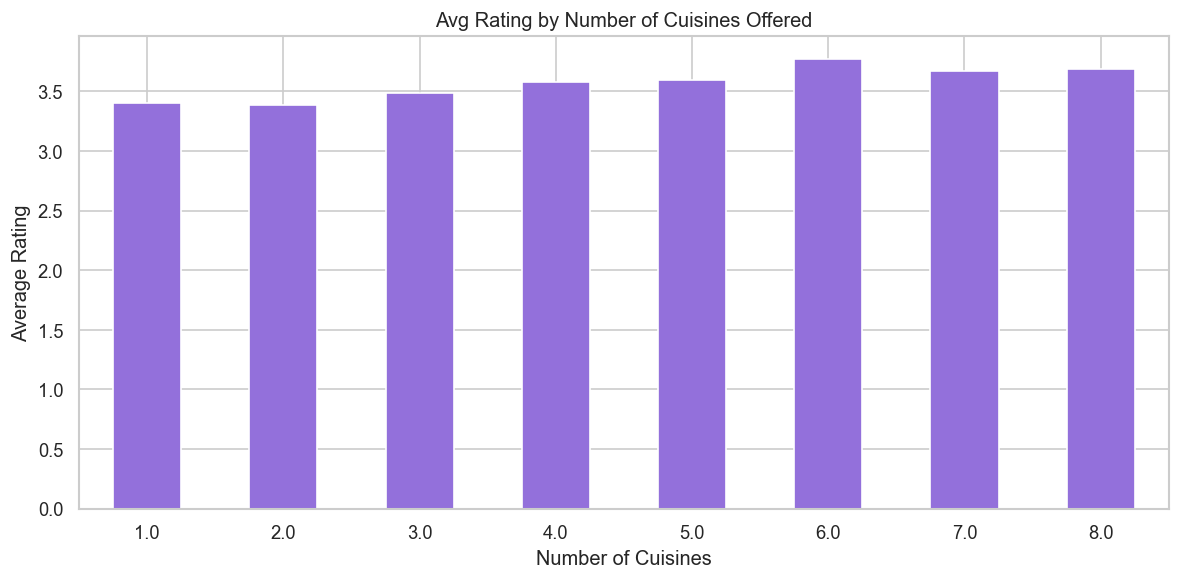

Cuisine Count
1.0    3.404
2.0    3.389
3.0    3.489
4.0    3.581
5.0    3.598
6.0    3.775
7.0    3.671
8.0    3.685
Name: Aggregate rating, dtype: float64


In [12]:
rated = df[df['Aggregate rating'] > 0]
cuisine_vs_rating = rated.groupby('Cuisine Count')['Aggregate rating'].mean().round(3)

fig, ax = plt.subplots(figsize=(10, 5))
cuisine_vs_rating.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Avg Rating by Number of Cuisines Offered')
ax.set_xlabel('Number of Cuisines')
ax.set_ylabel('Average Rating')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(cuisine_vs_rating)

### 3.4 — Name Length vs Rating

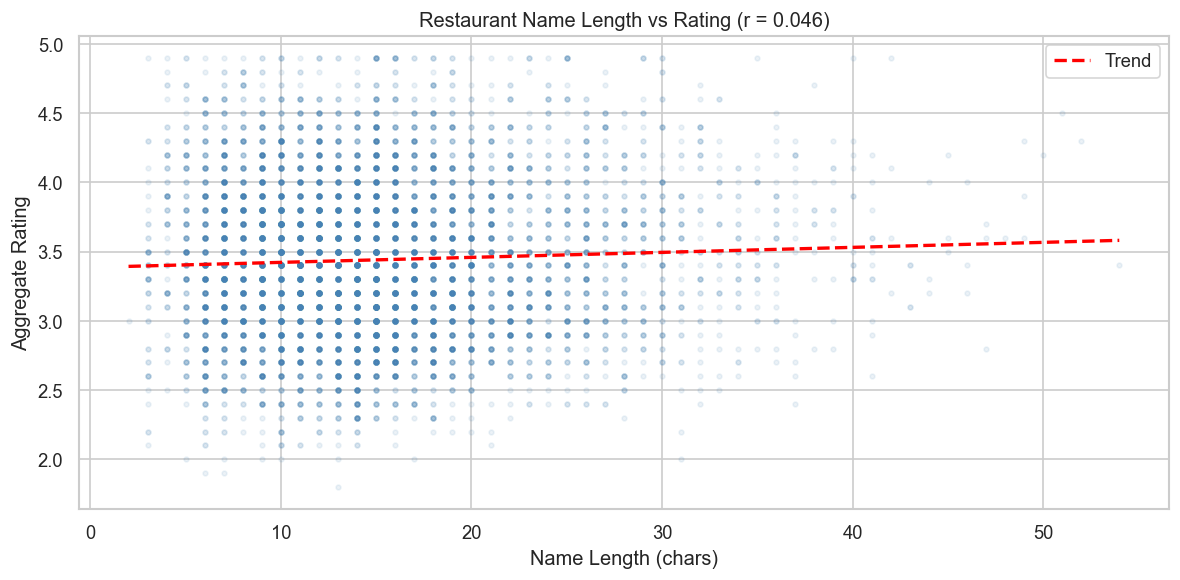

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(rated['Name Length'], rated['Aggregate rating'],
           alpha=0.1, s=8, color='steelblue')
# Trend line
z = np.polyfit(rated['Name Length'], rated['Aggregate rating'], 1)
p = np.poly1d(z)
x_range = np.linspace(rated['Name Length'].min(), rated['Name Length'].max(), 100)
ax.plot(x_range, p(x_range), color='red', linewidth=2, linestyle='--', label='Trend')
corr = rated['Name Length'].corr(rated['Aggregate rating'])
ax.set_title(f'Restaurant Name Length vs Rating (r = {corr:.3f})')
ax.set_xlabel('Name Length (chars)')
ax.set_ylabel('Aggregate Rating')
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 — Final Engineered Feature Summary

Engineered Feature Correlations with Aggregate Rating (rated only):
Cuisine Count          0.1164
Has Table booking      0.1123
Name Length            0.0460
Locality Length        0.0362
Is delivering now     -0.0232
Address Length        -0.0247
Has Online delivery   -0.0727
Name: Aggregate rating, dtype: float64


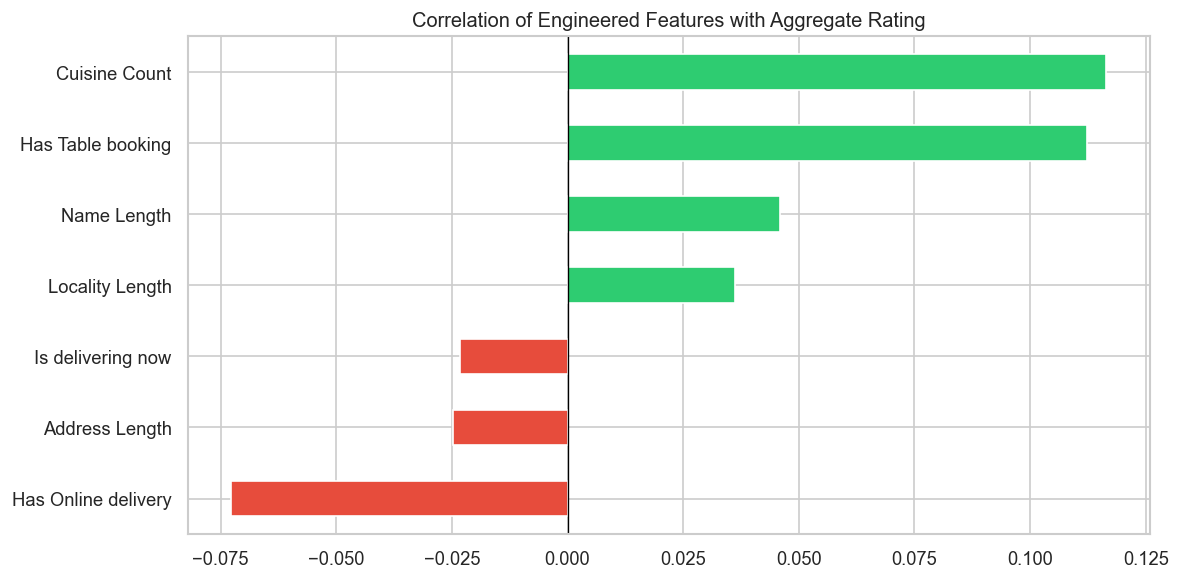

In [14]:
new_features = ['Name Length', 'Address Length', 'Locality Length', 'Cuisine Count',
                'Has Table booking', 'Has Online delivery', 'Is delivering now']

print('Engineered Feature Correlations with Aggregate Rating (rated only):')
rated = df[df['Aggregate rating'] > 0]
corr_series = rated[new_features + ['Aggregate rating']].corr()['Aggregate rating'].drop('Aggregate rating')
print(corr_series.sort_values(ascending=False).round(4))

# Visualise correlations
fig, ax = plt.subplots(figsize=(10, 5))
corr_series.sort_values().plot(kind='barh', ax=ax,
                                color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr_series.sort_values()],
                                edgecolor='white')
ax.set_title('Correlation of Engineered Features with Aggregate Rating')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [15]:
print('='*50)
print('Level 2 Complete ✓')
print('='*50)
print(f'New features added: {new_features}')
print(f'Final dataset shape: {df.shape}')

Level 2 Complete ✓
New features added: ['Name Length', 'Address Length', 'Locality Length', 'Cuisine Count', 'Has Table booking', 'Has Online delivery', 'Is delivering now']
Final dataset shape: (9551, 25)
